In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report#, accuracy_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import KFold
from sklearn import linear_model

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")

Here we learn/review some important metrics to assess the quality of a fitted model.

In [3]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [3]:
df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].fillna('NA')
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

Let's build the confussion matrix

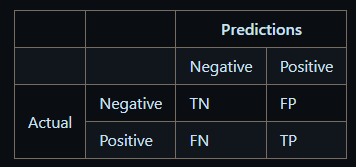

for the logistic regression model fitted in the previous chapter.

In [50]:
# Dataset splitting
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [47]:
# One-hot encoding
dicts = df.drop(['converted'], axis=1).to_dict(orient='records')
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

test_dict = df_test.to_dict(orient='records')
X_test = dv.transform(test_dict)


In [69]:
model = linear_model.LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, df_train.converted)
y_pred = model.predict_proba(X_val)[:, 1]
#Use model.predict(X_val) to get the predicted classes instead of probabilities, using a threshold of 0.5.

In [8]:
#Build the confussion matrix

# The true positives
TrPos = ((df_val["converted"] == 1) & (y_pred > 0.5)).sum()

# The true negatives
TrNeg = ((df_val["converted"] == 0) & (y_pred < 0.5)).sum()

# The false positives
FlPos = ((df_val["converted"] == 0) & (y_pred > 0.5)).sum()

# The false negatives
FlNeg = ((df_val["converted"] == 1) & (y_pred < 0.5)).sum()

# The confussion matrix
CfMat = np.array([[TrNeg, FlPos], [FlNeg, TrPos]])
print(CfMat)

[[ 67  63]
 [  8 155]]


We can also get the confussion matrix from a scikitlearn function.

In [37]:
y_intpred = model.predict(X_val)
print(confusion_matrix(df_val['converted'], y_intpred))

[[ 67  63]
 [  8 155]]


Among the different metrics of quality of a classification model, there are:

<img src="figs/classification_metrics.png" style="width: 50%; height: auto;">

Notice the definition here is displayed differently from what scikitlearn does. It can be different depending on the library.

In [38]:
print(classification_report(df_val['converted'], y_intpred))

              precision    recall  f1-score   support

           0       0.89      0.52      0.65       130
           1       0.71      0.95      0.81       163

    accuracy                           0.76       293
   macro avg       0.80      0.73      0.73       293
weighted avg       0.79      0.76      0.74       293



In [9]:
Rec = TrPos/(TrPos + FlNeg)
Pre = TrPos/(TrPos + FlPos)
F1sc = 2*Rec*Pre/(Rec + Pre)
print(f"Recall: {Rec:.2f}")
print(f"Precision: {Pre:.2f}")
print(f"f1-score: {F1sc:.2f}")

Recall: 0.95
Precision: 0.71
f1-score: 0.81


As we can see, scikitlearn gives us these metrics both for the "0" and "1" events.

Now, let' study the ROC (Receiver Operating Characteristics). Note that, even though the target variable is binary, the model returns real-valued outputs between 0 and 1. It is common to take a threshold of 0.5 to make the classification and compare with the actual values in the validation subset. But it might not be the best choice for a threshold value, depending on the dataset. This is where the so-called ROC curves enter.

In [96]:
scores = []
for t in np.linspace(0.,1.,101):
    # The true positives
    TrPos = ((df_val["converted"] == 1) & (y_pred > t)).sum()

    # The true negatives
    TrNeg = ((df_val["converted"] == 0) & (y_pred < t)).sum()

    # The false positives
    FlPos = ((df_val["converted"] == 0) & (y_pred > t)).sum()

    # The false negatives
    FlNeg = ((df_val["converted"] == 1) & (y_pred < t)).sum()

    scores.append((t, TrPos, TrNeg, FlPos, FlNeg))

scores = pd.DataFrame(scores, columns = ['threshold', 'tp', 'tn', 'fp', 'fn'])

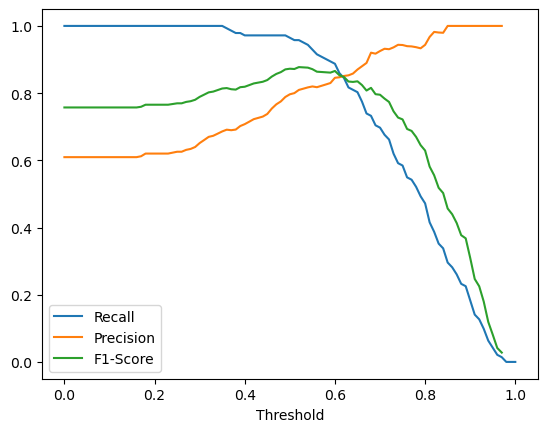

In [86]:
Rec = scores["tp"]/(scores["tp"] + scores["fn"])
Pre = scores["tp"]/(scores["tp"] + scores["fp"])
F1sc = 2*Rec*Pre/(Rec + Pre)

plt.plot(scores["threshold"], Rec, label="Recall")
plt.plot(scores["threshold"], Pre, label="Precision")
plt.plot(scores["threshold"], F1sc, label="F1-Score")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [78]:
print(np.argmin(np.abs(Rec - Pre)))
print(np.argmax(F1sc))

67
58


As we can see, the Recall and Precision curves intersect at the threshold value t = 0.67 and the F1 score attains it maximum value at t = 0.58.

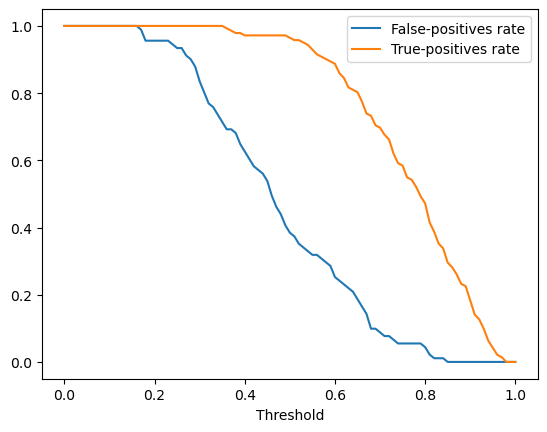

In [97]:
FPR = scores["fp"]/(scores["fp"] + scores["tn"])#Proportion of wrongly predicted positives among actual negatives
TPR = scores["tp"]/(scores["tp"] + scores["fn"])#Proportion of correctly predicted positives among actual positives

plt.plot(scores["threshold"], FPR, label="False-positives rate")
plt.plot(scores["threshold"], TPR, label="True-positives rate")
plt.xlabel("Threshold")
plt.legend()
plt.show()

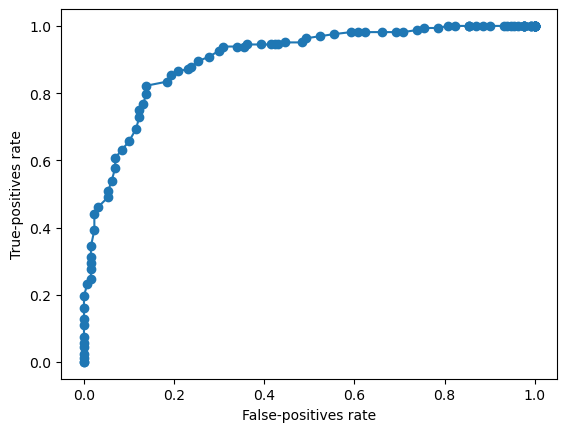

In [33]:
plt.plot(FPR, TPR, marker='o')
plt.xlabel("False-positives rate")
plt.ylabel("True-positives rate")
plt.show()

Alternative: using scikitlearn. In addition, we implement the function to compute the area under the ROC curve.

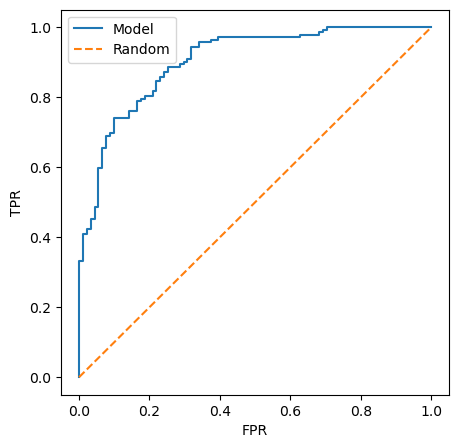

In [82]:
fpr, tpr, thresholds = roc_curve(df_val['converted'], y_pred)
 
plt.figure(figsize=(5,5))
 
plt.plot(fpr, tpr, label='Model')
plt.plot([0,1], [0,1], label='Random', linestyle='--')
 
plt.xlabel('FPR')
plt.ylabel('TPR')
 
plt.legend()

In [100]:
print(f"Area under the ROC curve: {auc(FPR, TPR)}")
print(f"Area : {roc_auc_score(df_val['converted'], y_pred)}")

Area under the ROC curve: 0.9019501625135427
Area : 0.9026466491255224


In [29]:
neg = y_pred[df_val['converted'] == 0]# A slice of the predicted values where the actual value is 0
pos = y_pred[df_val['converted'] == 1]# A slice of the predicted values where the actual value is 1

The area under the ROC curve tells us the probability that a randomly selected actual positive value has a greater score than a randomly selected actual negative value.

In [32]:
success = 0
n = 100000
for i in range(n):
  if pos[random.randint(0, len(pos) -1)] > neg[random.randint(0, len(neg) -1)]:
    success += 1

success/ n

0.90149

In [28]:
from matplotlib import cm

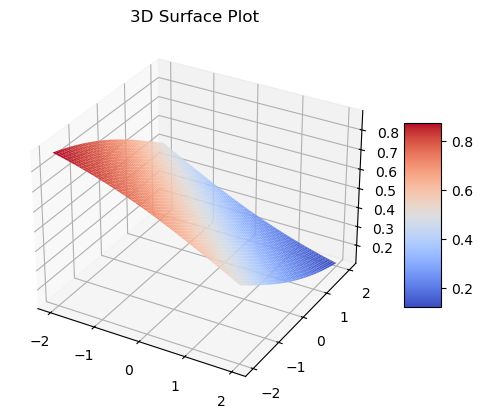

In [29]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
v = [0.5, 0.5]
# Generate coordinate grids and calculate surface
X, Y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
Z = 1./(1. + np.exp(v[0]*X + v[1]*Y))

# Plot the surface with a colormap
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_title('3D Surface Plot')
plt.show()

K-fold cross-validation: in order to assess the model for different subsets of the dataset, we split the train+validation subset into k subsets. Then, for every bipartition 1|(k-1) among these subsets, we train the model based on the (k-1) subsets and validate with the remaining subset by computing the AUC (area under the ROC curve) score. Afterward, we compute the mean and standard deviation of these score values.

In [105]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1) 
 
kfold.split(df_full_train)
 
train_idx, val_idx = next(kfold.split(df_full_train))# List of indices for the training and validation sets

In [81]:
scores = []
 
for train_idx, val_idx in kfold.split(df_full_train):

    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    train_dict = df_train.to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)
    
    val_dict = df_val.to_dict(orient='records')
    X_val = dv.transform(val_dict)
    
    y_train = df_train.converted
    y_val = df_val.converted
 
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
 
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

avrsc, stdsc = np.mean(scores), np.std(scores)
print(f"Mean AUC: {avrsc:.3f}, std: {stdsc:.3f}")

Mean AUC: 0.876, std: 0.032


Now, let's try with different regularization parameters.

In [108]:
scores = []
for c in [0.000001, 0.001, 1]:
    model = linear_model.LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=1)

    for train_idx, val_idx in kfold.split(df_full_train):

        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        train_dict = df_train.to_dict(orient='records')
        X_train = dv.fit_transform(train_dict)
        
        val_dict = df_val.to_dict(orient='records')
        X_val = dv.transform(val_dict)
        
        y_train = df_train.converted
        y_val = df_val.converted
    
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:, 1]
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    avrsc, stdsc = np.mean(scores), np.std(scores)
    print(f"C: {model.C}, Mean AUC: {avrsc:.3f}, std: {stdsc:.3f}")

C: 1e-06, Mean AUC: 0.561, std: 0.024
C: 0.001, Mean AUC: 0.744, std: 0.184
C: 1, Mean AUC: 0.788, std: 0.164


<Axes: xlabel='lead_score', ylabel='Count'>

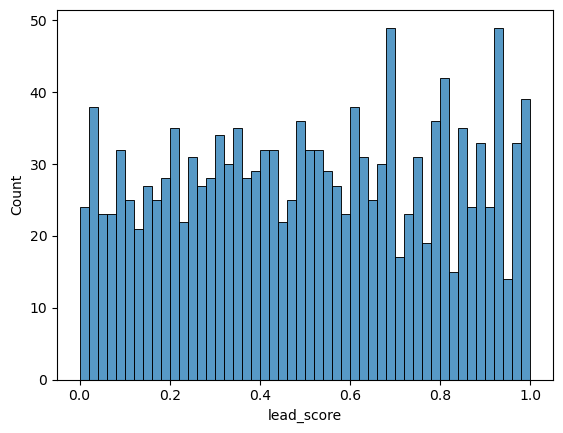

In [52]:
sns.histplot(df.lead_score, bins=50)

I have to compute the AUC score for every numerical variable, taking it as the prediction score, and the "converted" variable as the actual value. For variables that don't lie on the [0,1] interval, I linearly transform them by mapping $X_{nor} = (X - X_{min})/(X_{max} - X_{min})$.

In [101]:
roc_auc_score(df_train.converted, df_train.lead_score)

np.float64(0.6173635450170433)

In [102]:
nor_income = (df_train.annual_income - df_train.annual_income.min()) / (df_train.annual_income.max() - df_train.annual_income.min())
print(roc_auc_score(df_train.converted, nor_income))

0.5499425478007106


In [103]:
nor_courses = (df_train.number_of_courses_viewed - df_train.number_of_courses_viewed.min()) / (df_train.number_of_courses_viewed.max() - df_train.number_of_courses_viewed.min())
print(roc_auc_score(df_train.converted, nor_courses))

0.7475757094986033


In [104]:
nor_inter = (df_train.interaction_count - df_train.interaction_count.min()) / (df_train.interaction_count.max() - df_train.interaction_count.min())
print(roc_auc_score(df_train.converted, nor_inter))

0.7183327804460599


The "number_of_courses_viewed" variable is the one with the highest AUC score.

In [65]:
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

model = linear_model.LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, df_train.converted)
y_pred = model.predict(X_val)#model.predict_proba(X_val)[:, 1]

print(roc_auc_score(df_val.converted, y_pred))

0.7289329882082254
